# Faizaan Ali | HW6 | Task 2

## Denoising Diffusion Probabilistic Models (DDPM)

Mini Research Task

- Topic: Diffusion Models
- Primary Sources:
  
  Jonathan Ho, Ajay Jain, and Pieter Abbeel. 2020. Denoising diffusion probabilistic models. In Proceedings of the 34th International Conference on Neural Information Processing Systems (NIPS '20). Curran Associates Inc., Red Hook, NY, USA, Article 574, 6840–6851. [link text](https://arxiv.org/abs/2006.11239)

  Song, Jiaming, Chenlin Meng, and Stefano Ermon. "Denoising diffusion implicit models." arXiv preprint [arXiv:2010.02502 (2020).](https://arxiv.org/abs/2010.02502)

- Secondary Source: https://huggingface.co/docs/diffusers/v0.8.0/api/pipelines/ddpm
- Implementation: Hugging Face Diffusers

  Model Card https://github.com/forever208/DDPM-IP/blob/DDPM-IP/model-card.md

## Problem

Traditional generative models (GANs, VAEs) struggle with:
- Training instability (GANs)
- Blurry outputs (VAEs)

Goal: Learn a stable way to generate high-quality samples.

Diffusion models solve this by:
1. Gradually adding noise to data
2. Learning to reverse this process

## Core Idea

Diffusion models work in two phases:

Forward Process (q)
- Add Gaussian noise step-by-step
- Eventually turns image into pure noise

Reverse Process (p_θ)
- Neural network learns to remove noise
- Recovers structured image from noise

## Training Objective

The model is trained to **predict the noise** added to an image at a given timestep:

$
\epsilon_\theta(x_t, t) \approx \epsilon
$

- A clean image $x_0$ is gradually noised to produce $x_t$.  
- The model takes $x_t$ and timestep $t$ as input and predicts the noise $ϵ$ that was added.  

**Loss Function:**
- Mean Squared Error (MSE) between:
  - True noise $ϵ$
  - Predicted noise $\epsilon_\theta(x_t, t) \approx \epsilon$

$
\mathcal{L} = \| \epsilon - \epsilon_\theta(x_t, t) \|^2
$

**Why this works:**
- Predicting noise is **easier and more stable** than directly predicting the clean image.  
- Once the model can accurately estimate noise, it can **iteratively remove it**, reconstructing the original image during sampling.

## DDPM vs DDIM

| Aspect                | DDPM (Denoising Diffusion Probabilistic Model) | DDIM (Denoising Diffusion Implicit Model) |
|-----------------------|-----------------------------------------------|-----------------------------------------|
| Sampling         | Stochastic, fully probabilistic              | Deterministic / pseudo-stochastic       |
| Steps Needed      | Often requires hundreds of steps             | Can produce similar quality with fewer steps |
| Speed             | Slower due to many reverse steps             | Faster, fewer steps needed              |
| Image Quality     | High, stable outputs                          | Often sharper with fewer steps          |
| Use Case         | Standard training and generation             | Accelerated generation, faster demos    |

## Architectural Differences

- **DDPM**
  - Uses a U-Net backbone to predict noise at each timestep.
  - Fully stochastic reverse process: each step adds randomness via Gaussian sampling.
  - Relies on many timesteps (1000) for high-quality generation.

- **DDIM**
  - Shares the same U-Net architecture as DDPM for noise prediction.
  - Uses a deterministic or semi-deterministic reverse process, skipping intermediate stochasticity.
  - Can generate high-quality images with fewer timesteps (50–100) while reusing learned noise predictions.

**Summary:** DDIM is mostly a sampling modification, not a new network architecture. The core U-Net is the same; the difference lies in how the reverse diffusion steps are applied.

In [1]:
!pip install diffusers transformers accelerate torch matplotlib

# Import libraries
from diffusers import DDPMPipeline, DDIMPipeline
import torch
import matplotlib.pyplot as plt
import numpy as np

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Fixed seed for reproducibility
seed = 42
generator = torch.Generator(device=device).manual_seed(seed)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Pretrained Pipelines Used

- **DDPM Pipeline (`DDPMPipeline`)**  
  - Implements the original Denoising Diffusion Probabilistic Model.  
  - Uses a U-Net backbone trained on CIFAR-10 (32×32 images).  
  - Generates images via a stochastic reverse diffusion process with a specified number of timesteps.  

- **DDIM Pipeline (`DDIMPipeline`)**  
  - Uses the same pretrained U-Net as DDPM.  
  - Implements the Denoising Diffusion Implicit Model sampling method.  
  - Enables faster or deterministic generation by skipping or modifying intermediate stochastic steps.  

Both pipelines are loaded from the Hugging Face model hub (`google/ddpm-cifar10-32`) and allow controlled generation with a fixed random seed for reproducibility.  
[Model Card Reference](https://github.com/forever208/DDPM-IP/blob/DDPM-IP/model-card.md)

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

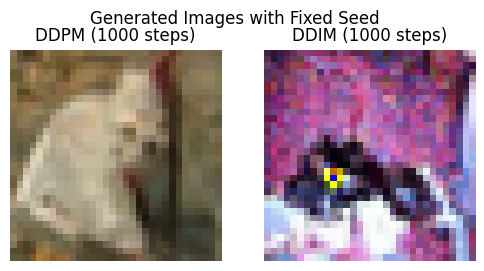

In [2]:
from diffusers import DDPMPipeline, DDIMPipeline
import torch
import matplotlib.pyplot as plt

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Fixed seed for reproducibility
seed = 42
generator = torch.Generator(device=device).manual_seed(seed)

# Load pretrained DDPM and DDIM pipelines
ddpm_pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
ddim_pipeline = DDIMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

# Generate a sample image with both pipelines
image_ddpm = ddpm_pipeline(generator=generator, num_inference_steps=1000).images[0]
image_ddim = ddim_pipeline(generator=generator, num_inference_steps=1000).images[0]

# Plot side-by-side
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(image_ddpm)
ax[0].axis("off")
ax[0].set_title("DDPM (1000 steps)")
ax[1].imshow(image_ddim)
ax[1].axis("off")
ax[1].set_title("DDIM (1000 steps)")
plt.suptitle("Generated Images with Fixed Seed")
plt.show()

Above, we can see the DDPM vs DDIM generated images for a given seed. Both images seem rather unintelligible, but have some notion of a general shape/form.

## Forward Diffusion DDPM

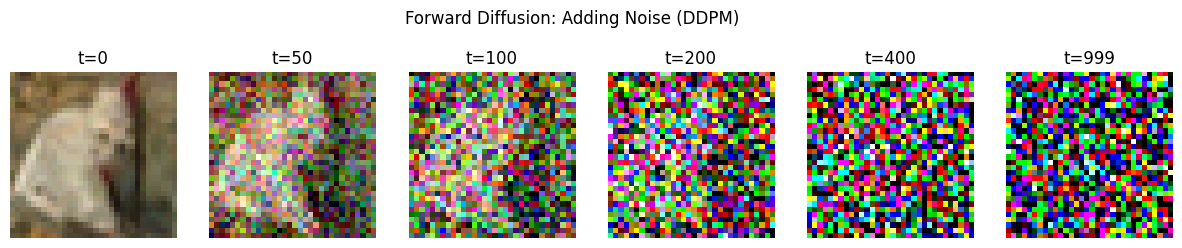

In [3]:
import numpy as np

# Convert DDPM sample to tensor
img_tensor = torch.tensor(np.array(image_ddpm)).permute(2,0,1).float()/255.0
img_tensor = img_tensor.to(device)

# Forward diffusion timesteps
timesteps_forward = [0, 50, 100, 200, 400, 999]
noisy_images = []

# Beta schedule from DDPM
beta = ddpm_pipeline.scheduler.betas
alpha = 1 - beta
alpha_cumprod = torch.cumprod(alpha.clone().detach(), dim=0).to(device)

x = img_tensor.unsqueeze(0)  # add batch dimension
for t in timesteps_forward:
    noise = torch.randn_like(x)
    alpha_t = alpha_cumprod[t]
    x_t = torch.sqrt(alpha_t) * x + torch.sqrt(1 - alpha_t) * noise
    noisy_images.append(x_t.squeeze(0).permute(1,2,0).cpu())

# Plot forward diffusion
fig, axes = plt.subplots(1, len(timesteps_forward), figsize=(15,3))
for i, img in enumerate(noisy_images):
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"t={timesteps_forward[i]}")
plt.suptitle("Forward Diffusion: Adding Noise (DDPM)")
plt.show()

### Forward Diffusion Visualization (DDPM)

- Converts a generated DDPM image to a tensor for computation.  
- Simulates the forward diffusion process: gradually adds Gaussian noise over selected timesteps (`t=0,50,100,...,999`).  
- Uses DDPM’s beta schedule to scale the noise and compute the cumulative alpha (`ᾱ_t`) for each timestep.  
  - In DDPMs, (α_t) represents the fraction of the original image that remains at timestep t during forward diffusion.  
- Shows how the image progressively degrades into noise, this is what the reverse process must learn to invert.  
- Since DDIM is a sampling method, there is no separate “forward diffusion” process to visualize; its forward pass is conceptually identical to DDPM’s, but the focus is on how it reverses noise efficiently.

## Reverse Diffusion Comparison
Experiment with varying number of steps

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

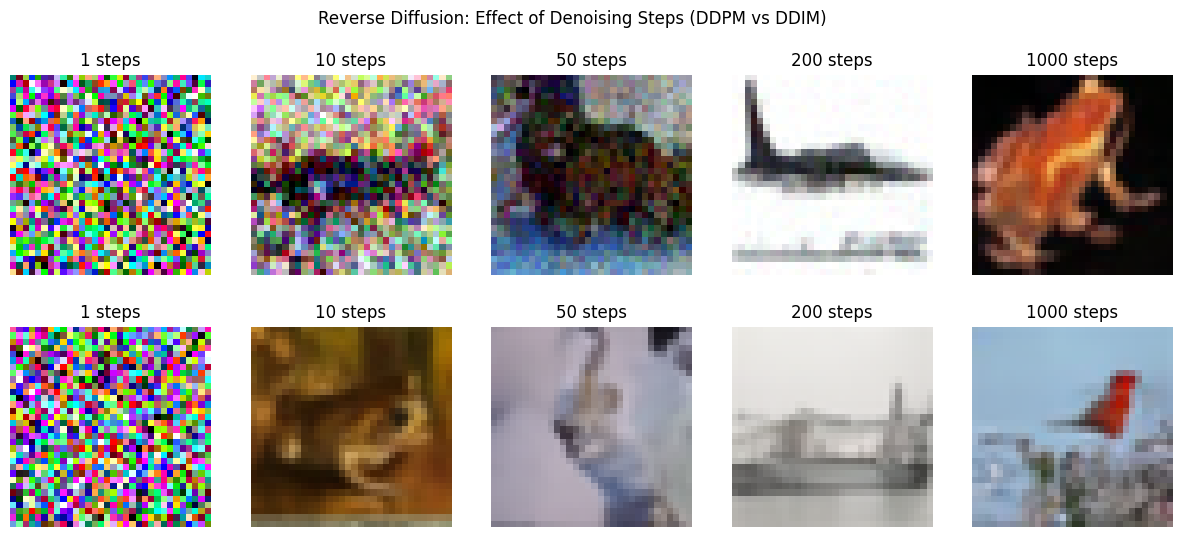

In [4]:
# Number of denoising steps to test
steps_list = [1, 10, 50, 200, 1000]

# Function to generate images for a pipeline
def generate_steps_images(pipeline, steps_list, generator):
    images = []
    for steps in steps_list:
        img = pipeline(generator=generator, num_inference_steps=steps).images[0]
        images.append(img)
    return images

# Generate images
images_ddpm = generate_steps_images(ddpm_pipeline, steps_list, generator)
images_ddim = generate_steps_images(ddim_pipeline, steps_list, generator)

# Plot side-by-side for comparison
fig, axes = plt.subplots(2, len(steps_list), figsize=(15,6))

for i, img in enumerate(images_ddpm):
    axes[0,i].imshow(img)
    axes[0,i].axis("off")
    axes[0,i].set_title(f"{steps_list[i]} steps")

for i, img in enumerate(images_ddim):
    axes[1,i].imshow(img)
    axes[1,i].axis("off")
    axes[1,i].set_title(f"{steps_list[i]} steps")

axes[0,0].set_ylabel("DDPM", rotation=0, labelpad=40, size=12)
axes[1,0].set_ylabel("DDIM", rotation=0, labelpad=40, size=12)
plt.suptitle("Reverse Diffusion: Effect of Denoising Steps (DDPM vs DDIM)")
plt.show()

### Effect of Number of Denoising Steps (DDPM vs DDIM)

- This cell compares how DDPM and DDIM pipelines generate images with different numbers of reverse diffusion (denoising) steps.  
- `steps_list` controls the number of inference steps used for each generation: fewer steps → faster but potentially lower-quality images.  
- Function `generate_steps_images`: iterates over the step values, generating one image per step count for a given pipeline.  
- Images are plotted side-by-side for DDPM (top row) and DDIM (bottom row) to highlight differences in quality and sharpness.  
- Observations:  
  - DDIM can produce sharper images with fewer steps.  
  - More steps generally improve fidelity but increase computation time.  

## DDPM vs DDIM Full Pipeline

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

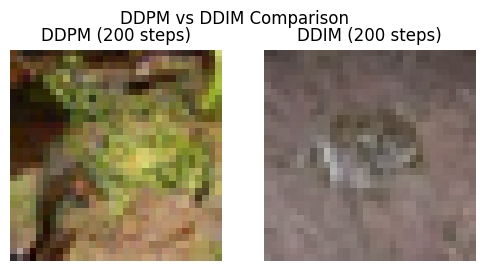

In [5]:
# Generate images with same seed
img_ddpm = ddpm_pipeline(generator=generator, num_inference_steps=200).images[0]
img_ddim = ddim_pipeline(generator=generator, num_inference_steps=200).images[0]

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].imshow(img_ddpm)
ax[0].set_title("DDPM (200 steps)")
ax[0].axis("off")

ax[1].imshow(img_ddim)
ax[1].set_title("DDIM (200 steps)")
ax[1].axis("off")

plt.suptitle("DDPM vs DDIM Comparison")
plt.show()

### DDPM vs DDIM Comparison (200 Steps)

- DDPM produces a recognizable but somewhat blurry and noisy image.  
- DDIM produces a smoother and less noisy image, but some fine details are lost or muted.  
- Both use the same number of denoising steps, but the sampling strategy differs:  
  - DDPM uses the original stochastic reverse process.  
  - DDIM uses a deterministic or semi-deterministic process that can reduce noise and increase sharpness.  
- Observation:
  - DDIM tends to generate visually cleaner outputs faster, while DDPM retains more stochastic texture and variability.

## Conclusion

When generating images with diffusion models, using more denoising steps generally produces higher-quality results, but at the cost of slower inference. Fewer steps are faster but tend to yield noisier or blurrier images. In our experiments, DDIM often produced sharper outputs with fewer steps compared to DDPM, highlighting a tradeoff between speed and image quality.  

There are several limitations to these models. Sampling can be slow because generating a single image requires many denoising steps. Training these models is demanding, making it resource-intensive to scale to larger datasets or higher-resolution images. Additionally, without conditioning, it is difficult to control the structure or content of the generated images precisely.  

There are also risks associated with diffusion models. They can be used to generate misleading synthetic data, which could be misinterpreted as real. Specifically, there is potential for misuse, such as creating deepfakes or other synthetic media that could be used maliciously. Moreover, the energy consumption for training and sampling is high, contributing to environmental concerns.

To address some of these issues, faster samplers or newer methods could be explored, such as reducing the number of steps using DDIM or adopting consistency models. A concrete follow-up experiment would be to compare DDPM with 200 steps against DDIM with 50 steps on denoising from the same seed, evaluating both visual quality and generation time. The goal would be to identify an optimal balance between speed and output quality.